In [1]:
import sys
sys.path.insert(0, '..')

# =====================================================
# EXPLORATORY ANALYSIS: METRICS OVER TIME
# =====================================================
# This notebook analyzes how metrics changes over time
# for different player types, with 95% confidence intervals.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Import utility functions from plot_utilities
from plot_utilities import (
    load_turn_data,
    setup_notebook_display,
    plot_metric_over_time  # Generalized function for any metric
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(12, 6))

# Load turn data with player type mapping automatically applied
turn_df = load_turn_data('../turn_data.csv', condition_exclude=["observe-vanilla-standard"])

d:\Cache\Onedrive - Arizona\OneDrive - University of Arizona\Vox Deorum\nlp-2026-tiny-4player\analysis\exploratory\..\plot_utilities.py:422: DtypeWarning: Columns (63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✓ Loaded turn data: 890680 rows
✓ Filters applied: condition_exclude=['observe-vanilla-standard']
✓ Unique conditions: 13
✓ Unique player types: 15
✓ Turn range: 0 - 500
✓ Unique civilizations: 43

Player Type Distribution:
  Vanilla: 293204 rows (32.9%)
  GLM-4.7-Simple: 75725 rows (8.5%)
  GLM-4.7-Briefed: 75725 rows (8.5%)
  GPT-OSS-120B-Simple: 59705 rows (6.7%)
  GPT-OSS-120B-Briefed: 59705 rows (6.7%)
  Kimi-K2.5-Simple: 58275 rows (6.5%)
  Kimi-K2.5-Briefed: 58275 rows (6.5%)
  Deepseek-3.2-Briefed: 49080 rows (5.5%)
  Deepseek-3.2-Simple: 49080 rows (5.5%)
  Minimax-M2.5-Simple: 31460 rows (3.5%)
  Minimax-M2.5-Briefed: 31460 rows (3.5%)
  Qwen-3.5-Briefed: 13301 rows (1.5%)
  Qwen-3.5-Simple: 13301 rows (1.5%)
  Sonnet-4.5-Briefed: 11192 rows (1.3%)
  Sonnet-4.5-Simple: 11192 rows (1.3%)

Condition Distribution:
  2026-deepseek-v-kimi2-v-glm-standard: 281688 rows (31.6%)
  2026-oss-v-glm-standard: 223776 rows (25.1%)
  2026-oss-v-qwen-v-minimax-standard: 73656 rows (8.3%)
  20

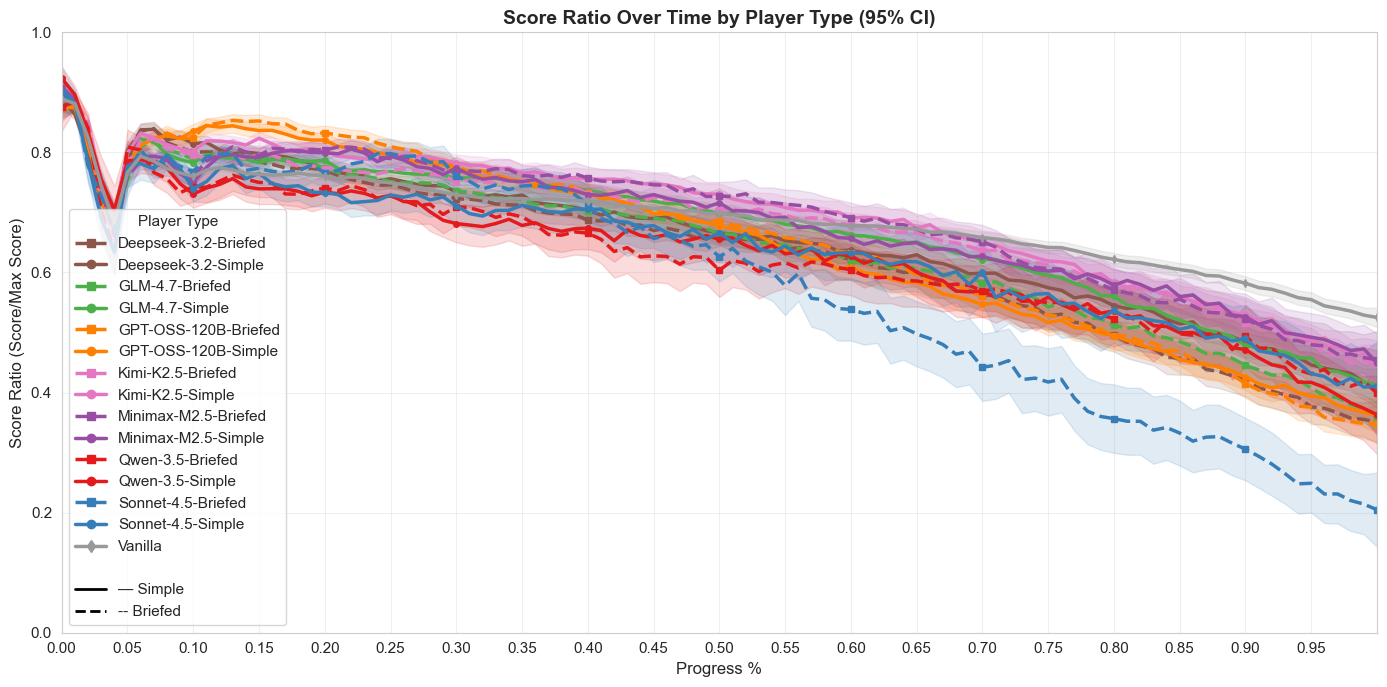

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.632,0.274,0.0,1.0,-0.458639,-0.484
Deepseek-3.2-Simple,49080,0.658,0.256,0.0,1.0,-0.387621,-0.439
GLM-4.7-Briefed,75725,0.643,0.260,0.0,1.0,-0.428055,-0.476
GLM-4.7-Simple,75725,0.671,0.238,0.0,1.0,-0.379281,-0.461
GPT-OSS-120B-Briefed,59705,0.653,0.277,0.0,1.0,-0.511597,-0.533
GPT-OSS-120B-Simple,59705,0.647,0.266,0.0,1.0,-0.501714,-0.545
Kimi-K2.5-Briefed,58275,0.683,0.252,0.0,1.0,-0.341489,-0.392
Kimi-K2.5-Simple,58275,0.697,0.259,0.0,1.0,-0.353690,-0.395
Minimax-M2.5-Briefed,31460,0.690,0.254,0.0,1.0,-0.345632,-0.394
Minimax-M2.5-Simple,31460,0.683,0.270,0.0,1.0,-0.339564,-0.364


In [2]:
# Plot score ratio over time using the generalized plot_metric_over_time function
# This calculates score_ratio as score/max_score dynamically
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['score'] / df['max_score'],
    title="Score Ratio Over Time by Player Type",
    ylabel="Score Ratio (Score/Max Score)",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 1)  # Score ratio is always between 0 and 1
)

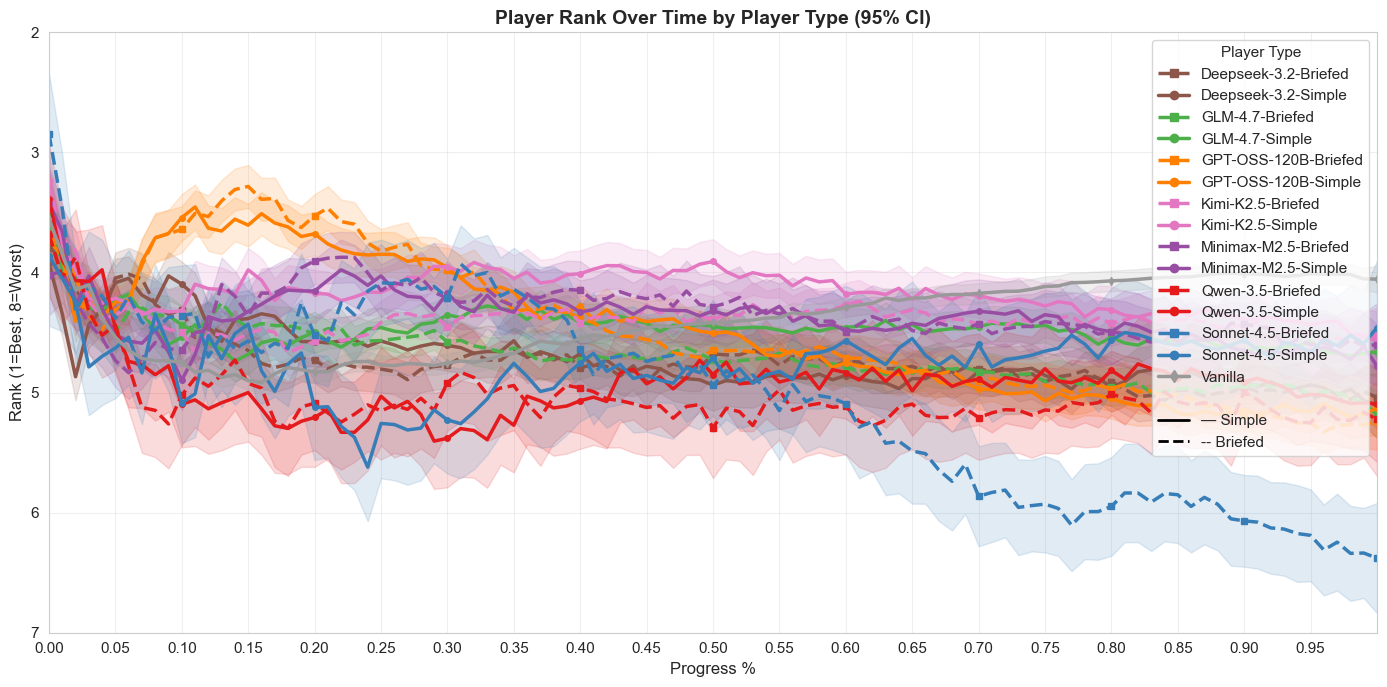

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,4.744,2.280,1,8,0.665014,0.084
Deepseek-3.2-Simple,49080,4.721,2.331,1,8,0.711022,0.088
GLM-4.7-Briefed,75725,4.698,2.244,1,8,0.770670,0.099
GLM-4.7-Simple,75725,4.469,2.223,1,8,0.266330,0.035
GPT-OSS-120B-Briefed,59705,4.474,2.387,1,8,1.813658,0.219
GPT-OSS-120B-Simple,59705,4.492,2.267,1,8,1.748201,0.223
Kimi-K2.5-Briefed,58275,4.388,2.299,1,8,0.111952,0.014
Kimi-K2.5-Simple,58275,4.165,2.338,1,8,0.337799,0.042
Minimax-M2.5-Briefed,31460,4.349,2.261,1,8,0.341451,0.044
Minimax-M2.5-Simple,31460,4.373,2.401,1,8,0.391534,0.047


In [3]:
# Create the rank over time plot with 95% confidence intervals
# Using the generalized plot_metric_over_time function
# Note: Lower rank is better (1 = first place, 4 = last place)
# We invert the y-axis to show better performance at the top
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='rank',  # Use the 'rank' column directly
    title="Player Rank Over Time by Player Type",
    ylabel="Rank (1=Best, 8=Worst)",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(2, 7),   # Set y-axis limits for rank (1-8 with padding)
    invert_y=True,     # Invert y-axis so lower (better) rank appears higher
    legend_loc='upper right'
)

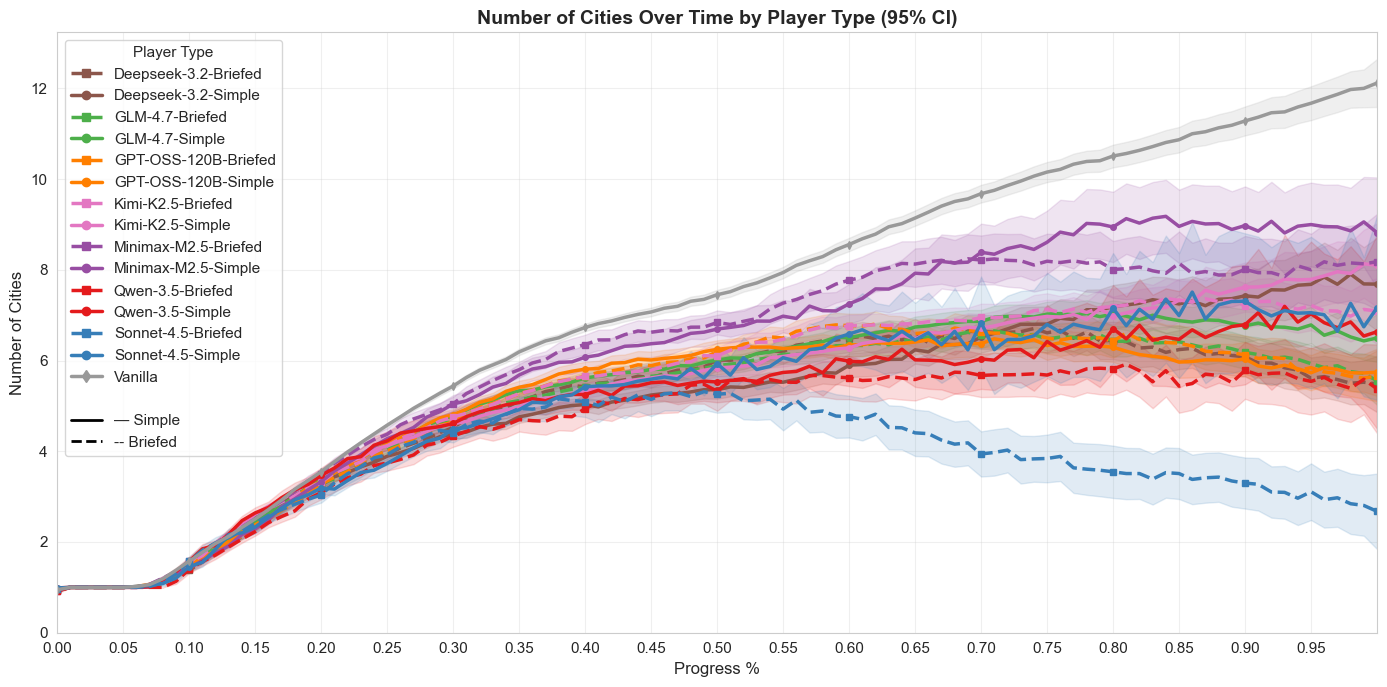

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,4.934,3.724,0,25,5.288115,0.411
Deepseek-3.2-Simple,49080,5.089,4.387,0,49,6.807391,0.449
GLM-4.7-Briefed,75725,4.963,3.762,0,41,5.362925,0.412
GLM-4.7-Simple,75725,5.230,3.651,0,31,6.066960,0.481
GPT-OSS-120B-Briefed,59705,5.060,3.768,0,24,5.337226,0.409
GPT-OSS-120B-Simple,59705,5.006,3.482,0,26,4.984234,0.413
Kimi-K2.5-Briefed,58275,5.355,4.014,0,39,6.571289,0.474
Kimi-K2.5-Simple,58275,5.296,4.357,0,58,6.866955,0.456
Minimax-M2.5-Briefed,31460,5.990,4.688,0,33,7.700454,0.475
Minimax-M2.5-Simple,31460,6.107,5.337,0,43,8.896314,0.482


In [4]:
# Plot number of cities over time using the generalized plot_metric_over_time function
# Cities are a key indicator of expansion and empire building in Civilization
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='cities',  # Use the 'cities' column directly
    title="Number of Cities Over Time by Player Type",
    ylabel="Number of Cities",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    use_turn_progress=True,
    print_summary=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Cities generally increase over time
)

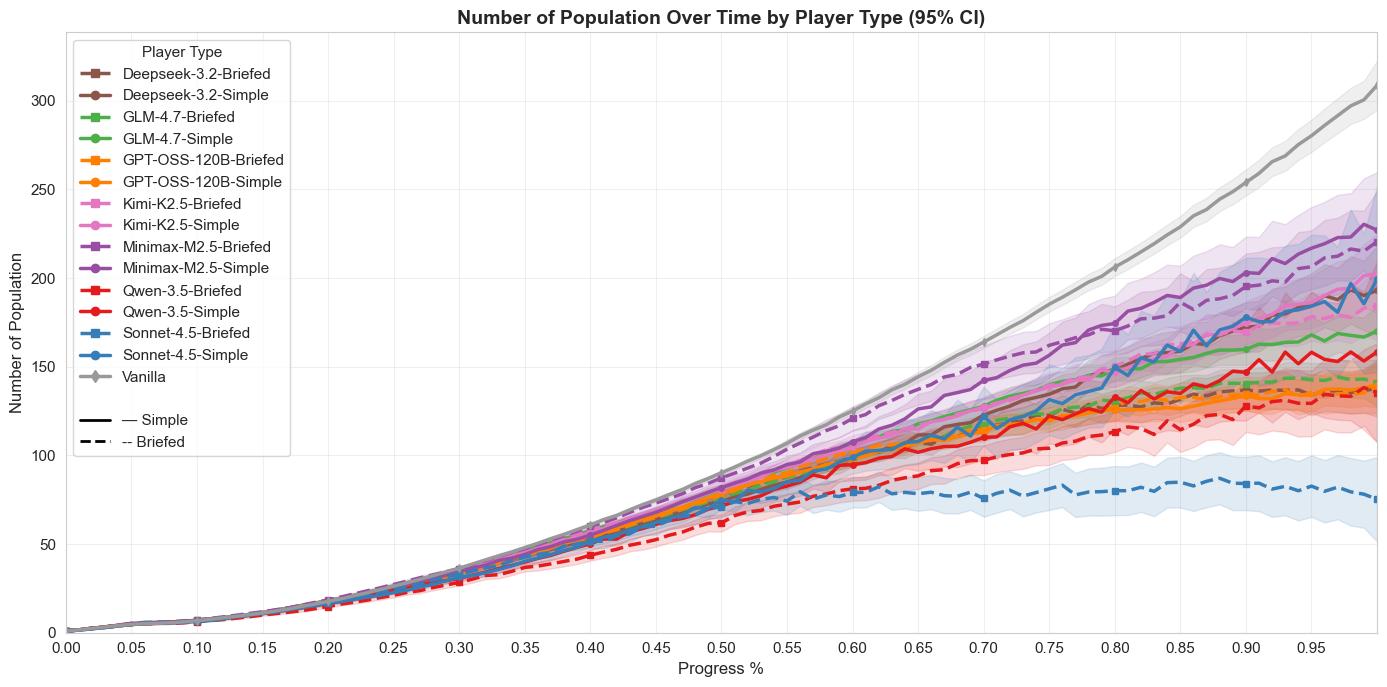

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,73.491,80.929,0,651,165.081347,0.590
Deepseek-3.2-Simple,49080,82.493,103.323,0,1122,207.760962,0.582
GLM-4.7-Briefed,75725,75.087,80.983,0,965,171.218871,0.611
GLM-4.7-Simple,75725,82.960,87.170,0,785,196.175006,0.651
GPT-OSS-120B-Briefed,59705,74.029,80.782,0,764,164.302765,0.587
GPT-OSS-120B-Simple,59705,73.387,74.697,0,603,162.160174,0.627
Kimi-K2.5-Briefed,58275,84.717,96.655,0,898,206.166334,0.617
Kimi-K2.5-Simple,58275,85.222,101.428,0,1322,211.410138,0.603
Minimax-M2.5-Briefed,31460,95.674,113.351,0,909,240.985150,0.615
Minimax-M2.5-Simple,31460,93.941,120.959,0,1277,247.553643,0.592


In [5]:
# Plot number of population over time using the generalized plot_metric_over_time function
# Cities are a key indicator of expansion and empire building in Civilization
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='population',  # Use the 'population' column directly
    title="Number of Population Over Time by Player Type",
    ylabel="Number of Population",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    use_turn_progress=True,
    print_summary=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Population generally increase over time
)

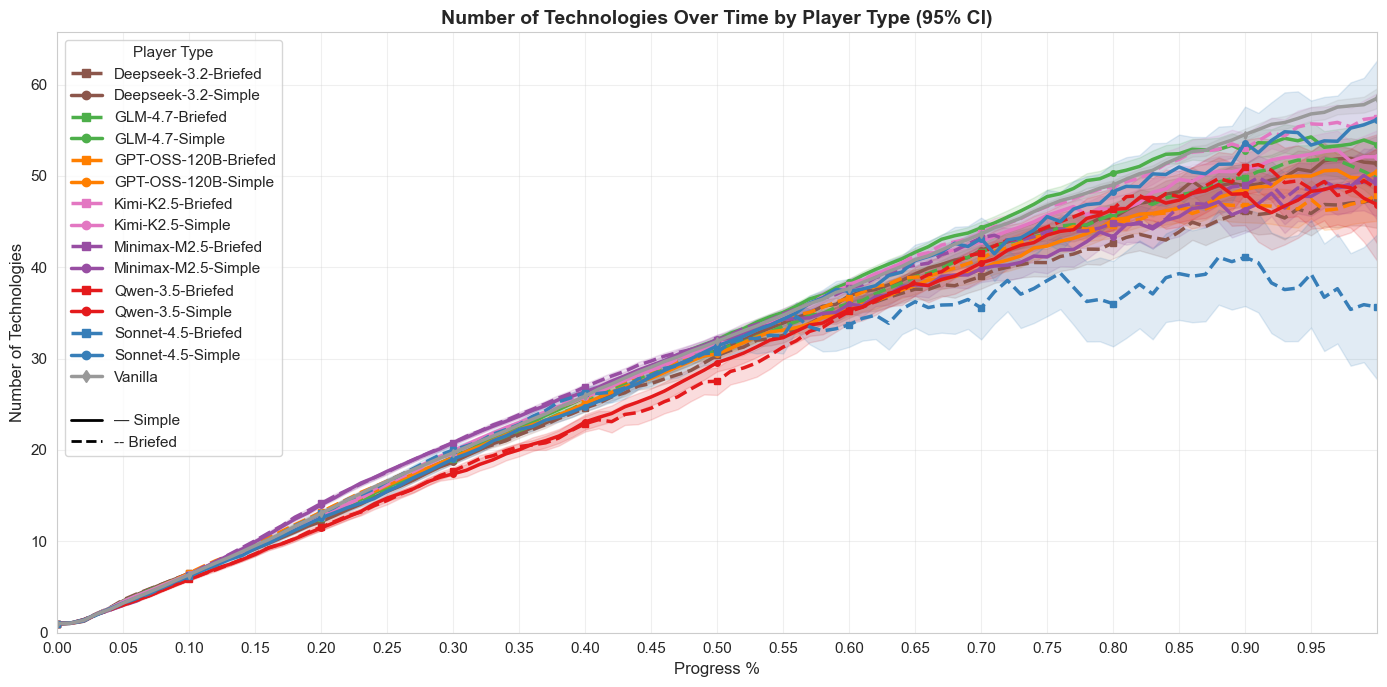

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,27.914,19.545,0,82,48.862040,0.723
Deepseek-3.2-Simple,49080,29.346,19.413,0,82,54.255968,0.809
GLM-4.7-Briefed,75725,29.484,19.841,0,82,54.081676,0.788
GLM-4.7-Simple,75725,31.098,19.979,0,82,58.789723,0.851
GPT-OSS-120B-Briefed,59705,29.164,19.154,0,82,50.265364,0.758
GPT-OSS-120B-Simple,59705,28.989,19.266,0,82,52.059756,0.780
Kimi-K2.5-Briefed,58275,30.955,20.314,0,82,58.883471,0.839
Kimi-K2.5-Simple,58275,30.240,20.006,0,82,55.464091,0.802
Minimax-M2.5-Briefed,31460,29.859,19.163,0,82,51.474675,0.777
Minimax-M2.5-Simple,31460,29.070,18.951,0,82,49.632785,0.758


In [6]:
# Plot number of technologies over time using the generalized plot_metric_over_time function
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='technologies',  # Use the 'technologies' column directly
    title="Number of Technologies Over Time by Player Type",
    ylabel="Number of Technologies",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Technology generally increase over time
)

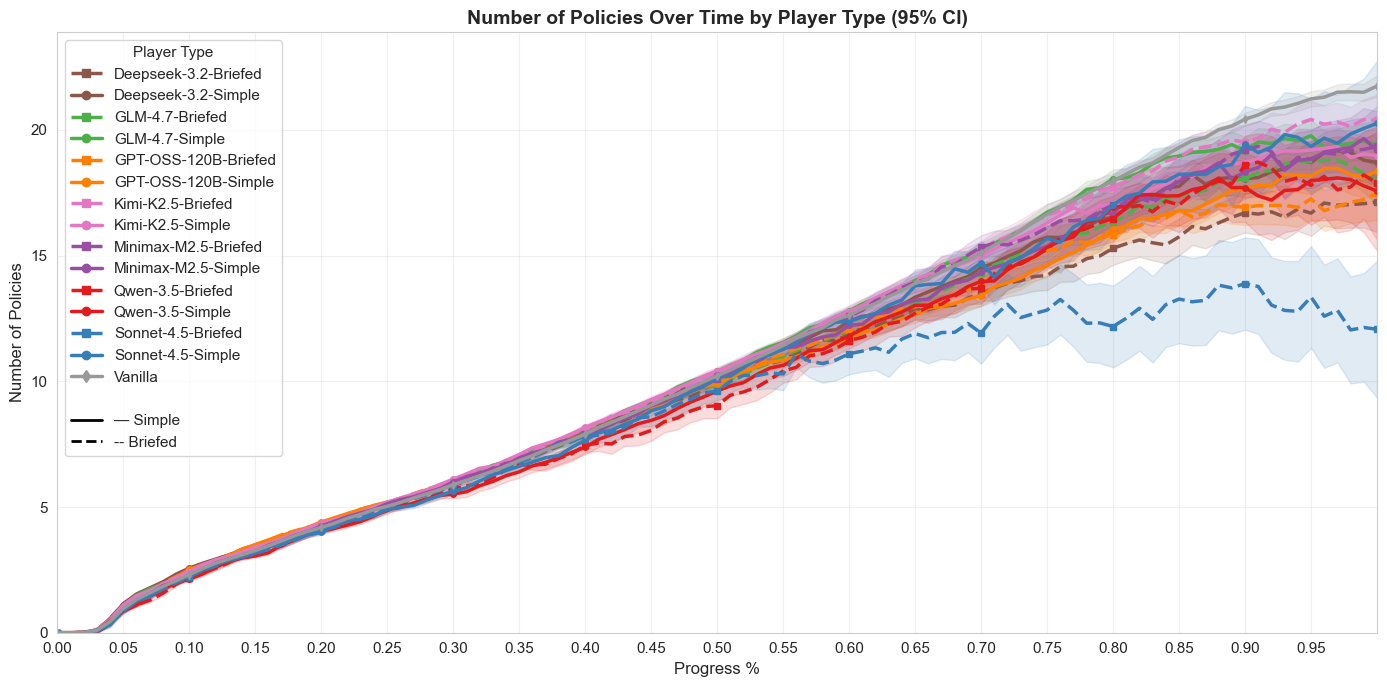

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,9.598,7.215,0,33,17.882528,0.717
Deepseek-3.2-Simple,49080,10.231,7.304,0,34,20.047977,0.794
GLM-4.7-Briefed,75725,10.081,7.333,0,33,19.847342,0.783
GLM-4.7-Simple,75725,10.670,7.411,0,35,21.508729,0.839
GPT-OSS-120B-Briefed,59705,9.869,7.133,0,38,18.497290,0.749
GPT-OSS-120B-Simple,59705,9.911,7.063,0,35,19.030839,0.778
Kimi-K2.5-Briefed,58275,10.665,7.728,0,36,21.869787,0.819
Kimi-K2.5-Simple,58275,10.473,7.552,0,35,20.730331,0.794
Minimax-M2.5-Briefed,31460,10.336,7.837,0,38,20.884649,0.771
Minimax-M2.5-Simple,31460,10.195,7.755,0,35,20.428603,0.762


In [7]:
# Plot number of policies over time using the generalized plot_metric_over_time function
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='policies',  # Use the 'policies' column directly
    title="Number of Policies Over Time by Player Type",
    ylabel="Number of Policies",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Technology generally increase over time
)